# Lab 3: Linear Spaces, Subspaces, Linear Transformations, Quotients, and Tensors

**MATH 5110 – Applied Linear Algebra and Matrix Analysis**  
**Chapter 3 companion lab**

This solutions notebook supports Chapter 3: *The Many Homes of Vectors: Spaces, Subspaces, and Linear Maps*.

The goal is to connect the abstract language of vector spaces with concrete computations in Python.
By the end of the lab, you should be able to:

1. represent polynomials, matrices, and linear maps using coordinate vectors;
2. test subspaces using closure and homogeneous equations;
3. compute spans, kernels, images, sums, and intersections;
4. connect linear transformations with matrix representations;
5. interpret quotient spaces computationally;
6. use Kronecker products as concrete tensor-product computations.

This notebook uses exact symbolic computation with `sympy` when possible and numerical computation with `numpy` for visualization.


> This version contains worked answers and complete code.

## 0. Setup

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

sp.init_printing()

# Symbols used throughout the lab
x, y, z, t = sp.symbols('x y z t')

# Useful helper functions

def rref_matrix(M):
    """Return the reduced row echelon form and pivot columns of a matrix."""
    M = sp.Matrix(M)
    R, pivots = M.rref()
    return R, pivots


def nullspace_basis(M):
    """Return a basis for the nullspace of M as sympy column vectors."""
    return sp.Matrix(M).nullspace()


def columnspace_basis(M):
    """Return a basis for the column space of M as sympy column vectors."""
    return sp.Matrix(M).columnspace()


def print_basis(name, basis):
    print(f"{name} has dimension {len(basis)}")
    for i, v in enumerate(basis, start=1):
        print(f"basis vector {i}:")
        display(v)

## 1. Polynomials as vectors — solutions

The coordinate matrix is

$$
P=\begin{bmatrix}
1&0&0\\
1&1&0\\
0&1&1\\
0&0&1
\end{bmatrix}.
$$

In [2]:
p1 = sp.Matrix([1, 1, 0, 0])
p2 = sp.Matrix([0, 1, 1, 0])
p3 = sp.Matrix([0, 0, 1, 1])
P = sp.Matrix.hstack(p1, p2, p3)
R, pivots = rref_matrix(P)
display(P)
display(R)
print("Pivot columns:", pivots)
print("The three polynomials are linearly independent because every column is a pivot column.")

⎡1  0  0⎤
⎢       ⎥
⎢1  1  0⎥
⎢       ⎥
⎢0  1  1⎥
⎢       ⎥
⎣0  0  1⎦

⎡1  0  0⎤
⎢       ⎥
⎢0  1  0⎥
⎢       ⎥
⎢0  0  1⎥
⎢       ⎥
⎣0  0  0⎦

Pivot columns: (0, 1, 2)
The three polynomials are linearly independent because every column is a pivot column.


In [3]:
alpha, beta, gamma, delta = sp.symbols('alpha beta gamma delta')
a, b, c = sp.symbols('a b c')
q = sp.Matrix([alpha, beta, gamma, delta])
sol = sp.solve(P*sp.Matrix([a,b,c]) - q, [a,b,c], dict=True)
sol

[]

From the equations

$$
a=\alpha,\qquad a+b=\beta,\qquad b+c=\gamma,\qquad c=\delta,
$$

we get

$$
\gamma=\beta-\alpha+\delta.
$$

Therefore

$$
\alpha+\beta t+\gamma t^2+\delta t^3\in W
\quad\Longleftrightarrow\quad
\gamma=\beta-\alpha+\delta.
$$

In [4]:
q1 = sp.Matrix([1, 2, 2, 1])
q2 = sp.Matrix([1, 2, 3, 1])

for name, qvec in [("q1", q1), ("q2", q2)]:
    print(name)
    try:
        sol = P.gauss_jordan_solve(qvec)
        print("belongs to W; coefficients are")
        display(sol[0])
    except ValueError as e:
        print("does not belong to W")

q1
belongs to W; coefficients are


⎡1⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣1⎦

q2
does not belong to W


## 2. Subspaces and non-subspaces — solutions

The homogeneous line $L$ contains the origin and is closed under linear combinations.
The affine line $H$ does not contain the origin, so it is not a subspace.

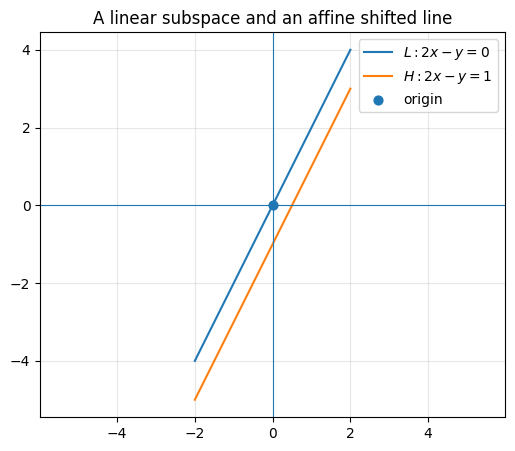

In [5]:
xs = np.linspace(-2, 2, 200)
L_y = 2 * xs
H_y = 2 * xs - 1

plt.figure(figsize=(6, 5))
plt.plot(xs, L_y, label=r"$L: 2x-y=0$")
plt.plot(xs, H_y, label=r"$H: 2x-y=1$")
plt.scatter([0], [0], s=40, label="origin")
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.legend()
plt.title("A linear subspace and an affine shifted line")
plt.show()

In [6]:
v = np.array([1, 1])
c = -1
print("v =", v, "is in C")
print("c =", c)
print("c*v =", c*v, "is not in C")

v = [1 1] is in C
c = -1
c*v = [-1 -1] is not in C


## 3. Span, planes, and implicit equations — solutions

In [7]:
u1 = sp.Matrix([1, 0, 2])
u2 = sp.Matrix([0, 1, -1])
a, b, c = sp.symbols('a b c')
n = sp.Matrix([a, b, c])
sol = sp.linsolve([sp.Eq(n.dot(u1), 0), sp.Eq(n.dot(u2), 0)], [a,b,c])
sol

{(-2⋅c, c, c)}

A normal vector is $(-2,1,1)$, so the plane equation is

$$
-2x+y+z=0,
$$

or equivalently

$$
z=2x-y.
$$

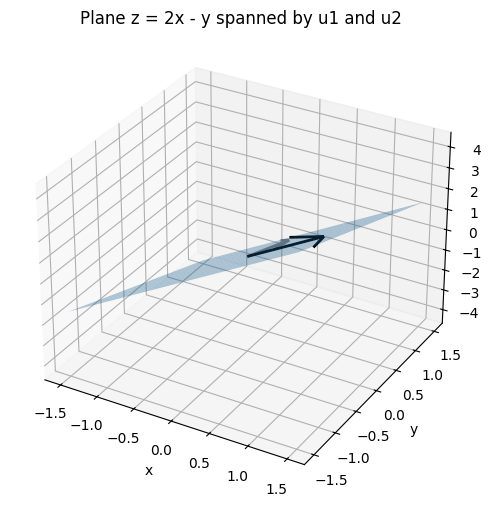

In [8]:
xx = np.linspace(-1.5, 1.5, 15)
yy = np.linspace(-1.5, 1.5, 15)
X, Y = np.meshgrid(xx, yy)
Z = 2*X - Y

fig = plt.figure(figsize=(7, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, alpha=0.35)
ax.quiver(0, 0, 0, 1, 0, 2, color='black', linewidth=2)
ax.quiver(0, 0, 0, 0, 1, -1, color='gray', linewidth=2)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_title('Plane z = 2x - y spanned by u1 and u2')
plt.show()

## 4. Sums and intersections — solutions

In [9]:
Umat = sp.Matrix([[1,0,1],
                  [0,1,1],
                  [1,1,2],
                  [0,0,0]])
Vmat = sp.Matrix([[1,0,1],
                  [0,1,1],
                  [0,0,0],
                  [1,1,2]])

basis_U = columnspace_basis(Umat)
basis_V = columnspace_basis(Vmat)
print_basis("U", basis_U)
print_basis("V", basis_V)

U has dimension 2
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

basis vector 2:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

V has dimension 2
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

basis vector 2:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [10]:
sum_matrix = sp.Matrix.hstack(Umat, Vmat)
basis_sum = columnspace_basis(sum_matrix)
print_basis("U + V", basis_sum)

U + V has dimension 3
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

basis vector 2:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

basis vector 3:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

In [11]:
block = sp.Matrix.hstack(Umat, -Vmat)
ns = nullspace_basis(block)
print_basis("nullspace of [U -V]", ns)

# Convert each solution (a,b) into an actual vector Umat*a in U ∩ V.
intersection_vectors = []
for s in ns:
    a_part = s[:Umat.shape[1], :]
    v_intersection = Umat * a_part
    if v_intersection != sp.zeros(4, 1):
        intersection_vectors.append(v_intersection)

# Remove repeated or dependent vectors by taking the column space of the matrix formed by them.
intersection_matrix = sp.Matrix.hstack(*intersection_vectors)
basis_intersection = columnspace_basis(intersection_matrix)
print_basis("U intersection V", basis_intersection)

nullspace of [U -V] has dimension 3
basis vector 1:


⎡-1⎤
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣0 ⎦

basis vector 2:


⎡-1⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢-1⎥
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎣0 ⎦

basis vector 3:


⎡-1⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢-2⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

U intersection V has dimension 1
basis vector 1:


⎡-1⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣0 ⎦

The intersection is one-dimensional:

$$
U\cap V=\operatorname{span}\{(1,-1,0,0)^T\}.
$$

The dimension formula gives

$$
\dim(U+V)=\dim U+\dim V-\dim(U\cap V)=2+2-1=3.
$$

## 5. Linear transformations: derivative map — solutions

In [12]:
# Basis in domain: 1, t, t^2, t^3
# D(1)=0, D(t)=1, D(t^2)=2t, D(t^3)=3t^2
Dmat = sp.Matrix([[0, 1, 0, 0],
                  [0, 0, 2, 0],
                  [0, 0, 0, 3]])
display(Dmat)

ker_D = nullspace_basis(Dmat)
im_D = columnspace_basis(Dmat)
print_basis("ker(D)", ker_D)
print_basis("im(D)", im_D)

⎡0  1  0  0⎤
⎢          ⎥
⎢0  0  2  0⎥
⎢          ⎥
⎣0  0  0  3⎦

ker(D) has dimension 1
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

im(D) has dimension 3
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣0⎦

basis vector 2:


⎡0⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣0⎦

basis vector 3:


⎡0⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣3⎦

In polynomial language,

$$
\ker(D)=\operatorname{span}\{1\},
$$

because constants differentiate to zero.  The image is all of $\mathbb R_2[t]$, so $D$ is surjective but not injective.

## 6. Kernel and image of a matrix transformation — solutions

In [13]:
A = sp.Matrix([[0, 0, 2, 8],
               [1, 5, 2, -5],
               [2,10, 6, -2]])
R, pivots = rref_matrix(A)
display(R)
print("Pivot columns:", pivots)

im_A = columnspace_basis(A)
ker_A = nullspace_basis(A)
print_basis("im(T)", im_A)
print_basis("ker(T)", ker_A)

rank = len(im_A)
nullity = len(ker_A)
print("rank =", rank)
print("nullity =", nullity)
print("rank + nullity =", rank + nullity)

⎡1  5  0  -13⎤
⎢            ⎥
⎢0  0  1   4 ⎥
⎢            ⎥
⎣0  0  0   0 ⎦

Pivot columns: (0, 2)
im(T) has dimension 2
basis vector 1:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣2⎦

basis vector 2:


⎡2⎤
⎢ ⎥
⎢2⎥
⎢ ⎥
⎣6⎦

ker(T) has dimension 2
basis vector 1:


⎡-5⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣0 ⎦

basis vector 2:


⎡13⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢-4⎥
⎢  ⎥
⎣1 ⎦

rank = 2
nullity = 2
rank + nullity = 4


The pivot columns are columns 1 and 3 in one-based indexing. Thus

$$
\operatorname{im}(T)=\operatorname{span}\left\{
\begin{bmatrix}0\\1\\2\end{bmatrix},
\begin{bmatrix}2\\2\\6\end{bmatrix}
\right\}.
$$

The kernel has basis

$$
\left\{
\begin{bmatrix}-5\\1\\0\\0\end{bmatrix},
\begin{bmatrix}13\\0\\-4\\1\end{bmatrix}
\right\}.
$$

## 7. Quotient spaces — solutions

In [14]:
n1 = sp.Matrix([1, 1, 0])
n2 = sp.Matrix([0, 1, 1])
Nmat = sp.Matrix.hstack(n1, n2)
a, b, c = sp.symbols('a b c')
ell = sp.Matrix([a, b, c])
sol = sp.linsolve([sp.Eq(ell.dot(n1), 0), sp.Eq(ell.dot(n2), 0)], [a,b,c])
sol

{(c, -c, c)}

A nonzero functional is

$$
\ell(x,y,z)=x-y+z.
$$

It vanishes on both generators of $N$, so $N\subseteq \ker(\ell)$. Since both subspaces have dimension $2$, actually $N=\ker(\ell)$.

In [15]:
v = sp.Matrix([2, 0, 1])
w = sp.Matrix([1, -1, 1])
diff = v - w
print("v-w =")
display(diff)

try:
    coeffs = Nmat.gauss_jordan_solve(diff)[0]
    print("v-w is in N, with coefficients")
    display(coeffs)
    print("Therefore v and w represent the same coset.")
except ValueError:
    print("v-w is not in N. Therefore v and w represent different cosets.")

print("ell(v) =", (v[0] - v[1] + v[2]))
print("ell(w) =", (w[0] - w[1] + w[2]))

v-w =


⎡1⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣0⎦

v-w is in N, with coefficients


⎡1⎤
⎢ ⎥
⎣0⎦

Therefore v and w represent the same coset.
ell(v) = 3
ell(w) = 3


## 8. Dual space — solutions

In [16]:
A0, A1, A2 = sp.symbols('A0 A1 A2')
p = A0 + A1*t + A2*t**2

epsilon0 = p.subs(t, 0)
epsilon1 = sp.diff(p, t).subs(t, 0)
epsilon2 = sp.diff(p, t, 2).subs(t, 0) / 2

epsilon0, epsilon1, epsilon2

(A₀, A₁, A₂)

The functionals recover the coordinate vector $(A_0,A_1,A_2)$ of the polynomial $p(t)=A_0+A_1t+A_2t^2$.

## 9. Tensor products and Kronecker products — solutions

In [17]:
v = sp.Matrix([2, -1])
w = sp.Matrix([3, 0, 4])
kron_vw = sp.kronecker_product(v, w)
outer = v*w.T
print("Kronecker coordinate vector:")
display(kron_vw)
print("Outer-product matrix:")
display(outer)

Kronecker coordinate vector:


⎡6 ⎤
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎢8 ⎥
⎢  ⎥
⎢-3⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣-4⎦

Outer-product matrix:


⎡6   0  8 ⎤
⎢         ⎥
⎣-3  0  -4⎦

In [18]:
A2 = sp.Matrix([[1, 2], [0, 1]])
B2 = sp.Matrix([[2, 0, 1], [1, 1, 0]])
x2 = sp.Matrix([1, -1])
y2 = sp.Matrix([2, 3, 1])

left = sp.kronecker_product(A2, B2) * sp.kronecker_product(x2, y2)
right = sp.kronecker_product(A2*x2, B2*y2)

display(left)
display(right)
print("Identity verified:", left == right)

⎡-5⎤
⎢  ⎥
⎢-5⎥
⎢  ⎥
⎢-5⎥
⎢  ⎥
⎣-5⎦

⎡-5⎤
⎢  ⎥
⎢-5⎥
⎢  ⎥
⎢-5⎥
⎢  ⎥
⎣-5⎦

Identity verified: True


## 10. Mini-project sample solution: Option C

In [19]:
B = sp.Matrix([[1,0,2,1],
               [0,1,-1,3],
               [1,1,1,4]])
R, piv = rref_matrix(B)
display(R)
print("Pivot columns:", piv)
print_basis("ker(T)", nullspace_basis(B))
print_basis("im(T)", columnspace_basis(B))
print("rank =", B.rank(), "nullity =", len(B.nullspace()))
print("T is injective?", len(B.nullspace()) == 0)
print("T is surjective onto R^3?", B.rank() == 3)

⎡1  0  2   1⎤
⎢           ⎥
⎢0  1  -1  3⎥
⎢           ⎥
⎣0  0  0   0⎦

Pivot columns: (0, 1)
ker(T) has dimension 2
basis vector 1:


⎡-2⎤
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎢1 ⎥
⎢  ⎥
⎣0 ⎦

basis vector 2:


⎡-1⎤
⎢  ⎥
⎢-3⎥
⎢  ⎥
⎢0 ⎥
⎢  ⎥
⎣1 ⎦

im(T) has dimension 2
basis vector 1:


⎡1⎤
⎢ ⎥
⎢0⎥
⎢ ⎥
⎣1⎦

basis vector 2:


⎡0⎤
⎢ ⎥
⎢1⎥
⎢ ⎥
⎣1⎦

rank = 2 nullity = 2
T is injective? False
T is surjective onto R^3? False


For Option C, the domain dimension is $4$ and the codomain dimension is $3$.  The rank is $2$, so the map is not surjective.  The nullity is $2$, so the map is not injective.